# Palace Eigenmode and Surface EPR for a QPDK Transmon

> **Recorded partial run.** These outputs were captured while inspecting an out-of-memory Palace return on 2026-09-24. SCGSim selected the last readable `iteration08` snapshot; the run did not complete and no converged Surface-EPR result is claimed. The raw returned package is not distributed. The historical solve used SCGSim dev27 and Palace v0.16.1; this notebook now installs dev28 for local analysis. Interactive Plotly outputs are stored as static images for the documentation build.



This notebook builds a public QPDK double-pad transmon, compiles its authored
component and process semantics with SCGSim, and specifies a manual single-node
Slurm handoff for a two-mode Palace eigenmode solve. It never submits or runs the
solver.

Route A uses the single-face `substrate_face` profile. SCGSim creates the
background vacuum around the authored substrate and metal; this notebook does
not add an artificial second metal face. Preparation generates a mesh, config,
and Slurm handoff, but does not establish a Palace solve or Surface-EPR result.

The installation command pins the source revision. SCGSim handoff receipts record
its package version, not the Git commit; a receipt alone does not prove that pin.

In this QPDK checkout, install the public, revision-pinned SCGSim package
into the project environment with Python 3.13:

```bash
uv sync --python 3.13 --group palace-notebook
```
Select `.venv/bin/python` as the Jupyter kernel.

Palace itself is an external executable. The handoff stage records the caller's
executable name, setup commands, and requested Slurm resources without assuming a
cluster configuration.

In [1]:
from pathlib import Path

from IPython.display import display
from scgsim.palace import (
    EigenmodeSim,
    inspect_run_trustworthiness,
    resolve_palace_result,
)
from scgsim.sgb import build_component_stack
from scgsim.visualization import inspect_palace_geometry

from qpdk import LAYER, PDK
from qpdk.cells.transmon import double_pad_transmon
from qpdk.tech import LAYER_STACK_NO_VACUUM, material_properties

PDK.activate()

WORKFLOW_ACTION = "analyze-returned"  # "prepare" or "analyze-returned"
RUN_ID = "transmon-epr-f1-amr3-20260923"
RUN_ROOT = Path(".artifacts") / "palace_transmon_surface_epr"
RUN_DIR = RUN_ROOT / RUN_ID

if WORKFLOW_ACTION not in {"prepare", "analyze-returned"}:
    raise ValueError("WORKFLOW_ACTION must be 'prepare' or 'analyze-returned'.")

2026-09-25 02:09:10.897 | WARNING  | qpdk:<module>:55 - QPDK models could not be loaded (No module named 'jax'). Ensure dependencies are installed with `pip install qpdk[models]`.


## Build Component Coupon

QPDK owns the substrate, metal, material, conductor, net, and selector facts.
A notebook-local copy omits QPDK's explicit Vacuum and its legacy M1 host
reference; SCGSim builds the background vacuum from the remaining stack.

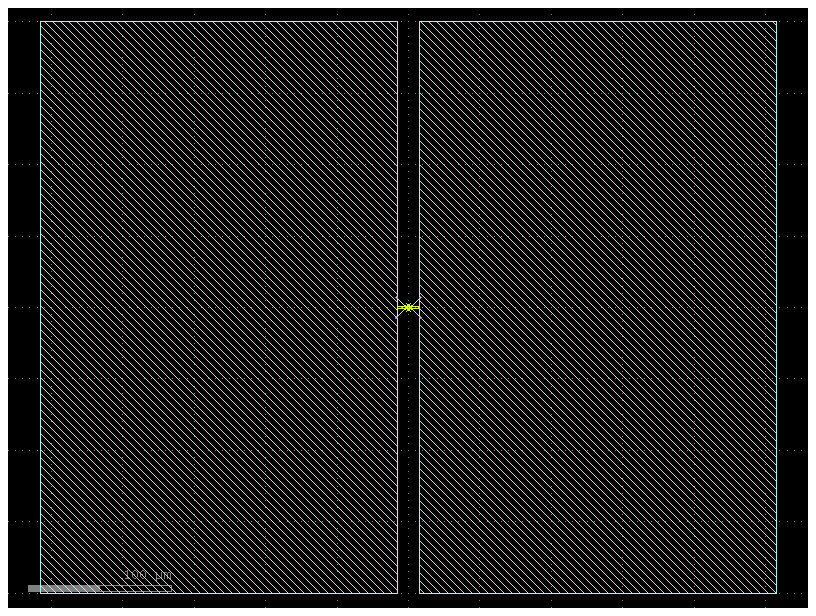

In [2]:
PAD_SIZE_UM = (250.0, 400.0)
PAD_GAP_UM = 15.0
JUNCTION_LUMPED_PORT_WIDTH_UM = 1.0
COUPON_PADDING_UM = 100.0

component = double_pad_transmon(
    pad_size=PAD_SIZE_UM,
    pad_gap=PAD_GAP_UM,
    with_junction_lumped_port=True,
    junction_lumped_port_width=JUNCTION_LUMPED_PORT_WIDTH_UM,
    layer_simulation=LAYER.SIM_BOUNDARY,
)
simulation_layer_stack = LAYER_STACK_NO_VACUUM.model_copy(deep=True)
del simulation_layer_stack.layers["M1"].info["host_void_semantic_id"]
stack = build_component_stack(
    component=component,
    layer_stack=simulation_layer_stack,
    material_records=material_properties,
    coupon_padding_um=COUPON_PADDING_UM,
)
component.plot()

## Configure EPR / Problem

The three 2 nm interface layers below are a caller-selected loss model based on
representative MA, MS, and SA parameters reported by
:cite:p:`woodsDeterminingInterfaceDielectric2019`. They are simulation inputs for
this example, not QPDK process truth. The junction inductance is likewise an
explicit caller model rather than a fabricated-junction parameter supplied by QPDK.

In [3]:
SURFACE_EPR_SPECS = {
    "MA": {
        "thickness": 0.002,
        "permittivity": 10.0,
        "loss_tangent": 0.0033,
    },
    "MS": {
        "thickness": 0.002,
        "permittivity": 11.4,
        "loss_tangent": 0.00048,
    },
    "SA": {
        "thickness": 0.002,
        "permittivity": 4.0,
        "loss_tangent": 0.0017,
    },
}
JUNCTION_INDUCTANCE_H = 7e-9
NUM_MODES = 2
# Caller-selected lower search bound in Hz, not a predicted resonance.
TARGET_HZ = 2e9
EIGENMODE_TOLERANCE = 1e-6
# Number of mode fields saved for visualization; zero saves none.
SAVE_FIELDS = 0
# Extend the generated vacuum 500 um above the top of M1.
VACUUM_PADDING_UM = {"z_plus_um": 500.0}

if WORKFLOW_ACTION == "prepare":
    if RUN_DIR.exists():
        raise FileExistsError(
            f"{RUN_DIR} already exists; choose a fresh RUN_ID for preparation."
        )
    sim = EigenmodeSim()
    sim.set_geometry(component)
    sim.set_stack(stack)
    sim.set_vacuum_region(padding=VACUUM_PADDING_UM)
    sim.set_output_dir(RUN_DIR)
    sim.set_surface_epr(
        representation="A",
        specs=SURFACE_EPR_SPECS,
        route_a_thin_film="substrate_face",
    )
    sim.add_port(
        "junction_lumped",
        layer="M1",
        layout_sheet=True,
        inductance=JUNCTION_INDUCTANCE_H,
    )
    sim.set_eigenmode(
        num_modes=NUM_MODES,
        target=TARGET_HZ,
        tolerance=EIGENMODE_TOLERANCE,
        save=SAVE_FIELDS,
    )

## Build Mesh

These Route A sizes are visible starting values in micrometres. Review the mesh
and quality evidence before treating a returned solve as scientific evidence.

In [4]:
REFINED_MESH_SIZE_UM = 2.0
MAX_MESH_SIZE_UM = 40.0

if WORKFLOW_ACTION == "prepare":
    sim.set_mesh(
        refined_mesh_size=REFINED_MESH_SIZE_UM,
        max_mesh_size=MAX_MESH_SIZE_UM,
    )
    mesh_path = sim.mesh()
    display(mesh_path)

## Generate Config

Allow up to 20 AMR iterations; nonconformal refinement remains disabled.

In [5]:
FEM_ORDER = 3
LINEAR_TOLERANCE = 1e-6
LINEAR_MAX_ITERATIONS = 400
AMR_MAX_PASSES = 20
AMR_NONCONFORMAL = False
AMR_TOLERANCE = 1e-2
AMR_UPDATE_FRACTION = 0.3

if WORKFLOW_ACTION == "prepare":
    sim.set_numerical(
        order=FEM_ORDER,
        tolerance=LINEAR_TOLERANCE,
        max_iterations=LINEAR_MAX_ITERATIONS,
        solver_type="Default",
        preconditioner="Default",
        device="CPU",
        amr_max_passes=AMR_MAX_PASSES,
        amr_nonconformal=AMR_NONCONFORMAL,
        amr_tolerance=AMR_TOLERANCE,
        amr_update_fraction=AMR_UPDATE_FRACTION,
        output_paraview=True,
    )
    config_path = sim.write_config()
    display(config_path)

## Prepare Handoff

This stage creates the portable archive and `run_palace.sbatch`; it does not run
`sbatch`. Adjust the executable, setup commands, and resource request to the target
cluster before preparing a new handoff.

In [6]:
PALACE_EXECUTABLE = "palace"
SLURM_SETUP_COMMANDS = ()
SLURM_RESOURCES = {
    "nodes": 1,
    "ntasks": 4,
    "cpus_per_task": 1,
    "time": "01:00:00",
    "mem": "16G",
    "job_name": "qpdk-transmon-epr",
}

if WORKFLOW_ACTION == "prepare":
    handoff = sim.prepare_handoff(
        profile="slurm-single-node",
        executable=PALACE_EXECUTABLE,
        resources=SLURM_RESOURCES,
        setup_commands=SLURM_SETUP_COMMANDS,
    )
    display({
        "handoff_id": handoff.handoff_id,
        "archive": handoff.archive_path,
        "script": handoff.script_path,
    })

## Analyze Returned Run

In preparation mode, inspect the generated mesh's structured Surface-EPR
assignments before sending the archive to the cluster. After the package
is returned, change `WORKFLOW_ACTION` to `"analyze-returned"`, keep the same
`RUN_ID`, and paste the exact handoff ID displayed above into the stage-local control
below. Extract the returned package into a separate directory and set
`RETURNED_RUN_DIR` to its run root (the directory containing `metadata`).
Trust inspection exposes readable snapshots from failed runs as partial
evidence. Completed runs additionally require strict receipt resolution.

The report order is run identity and numerical evidence, simulation cost, then
physics quantities. A returned package without bound Surface-EPR snapshots fails
rather than presenting an empty report as success.

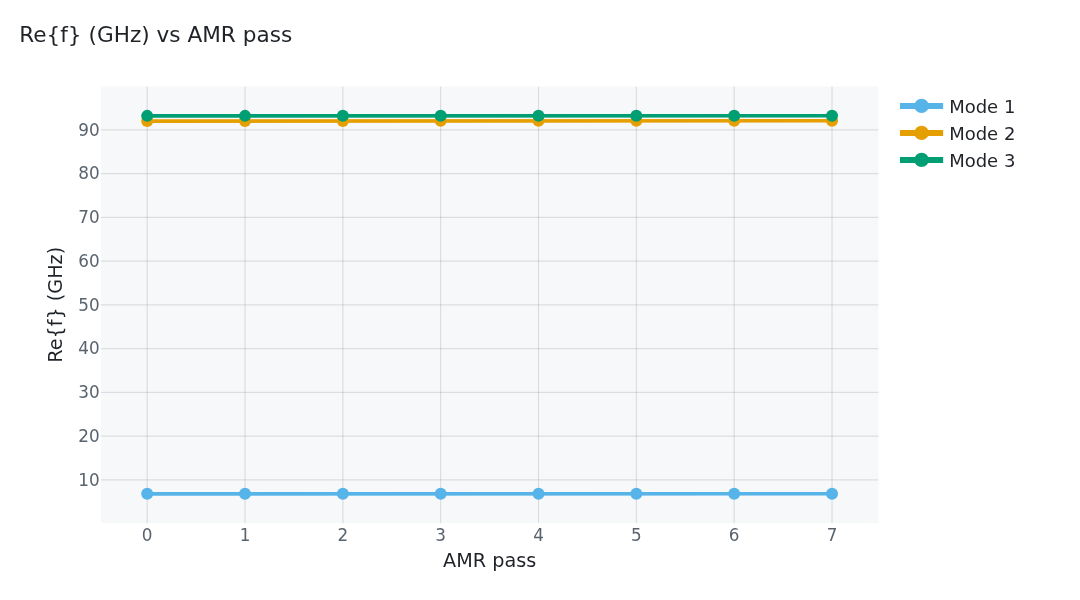

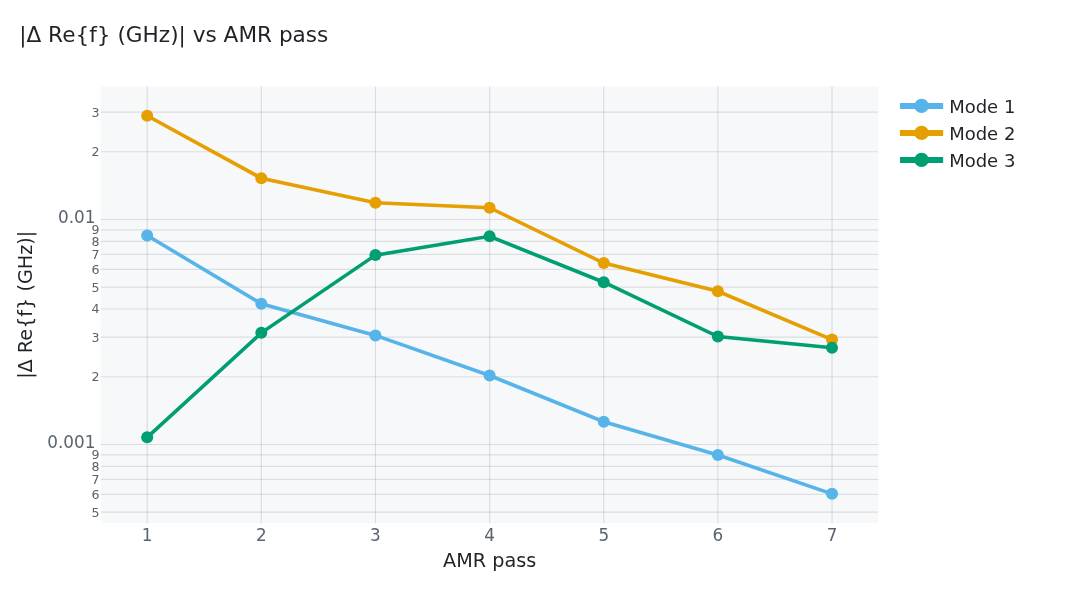

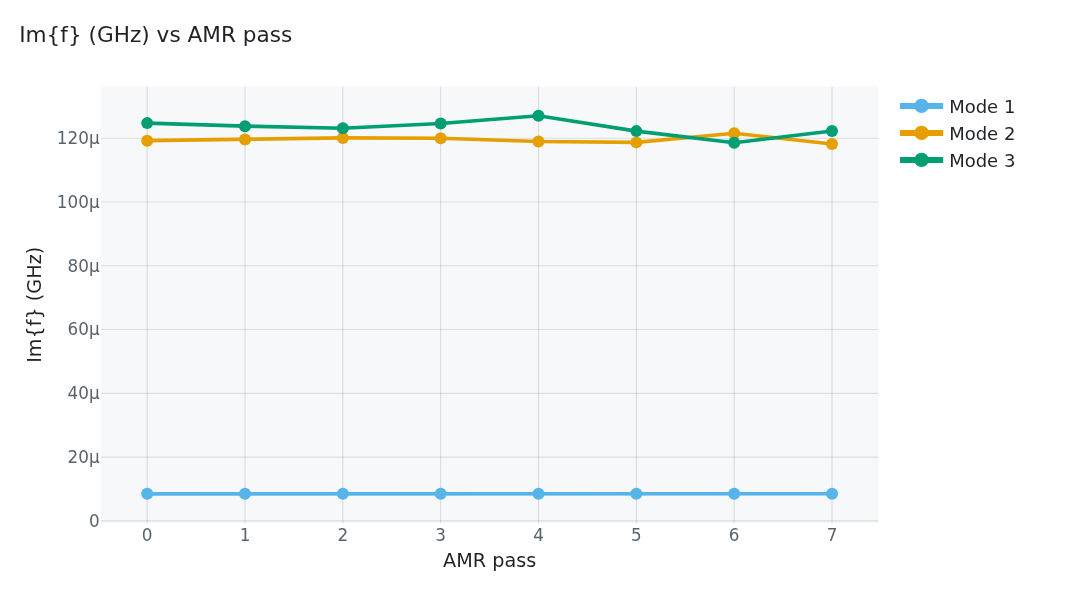

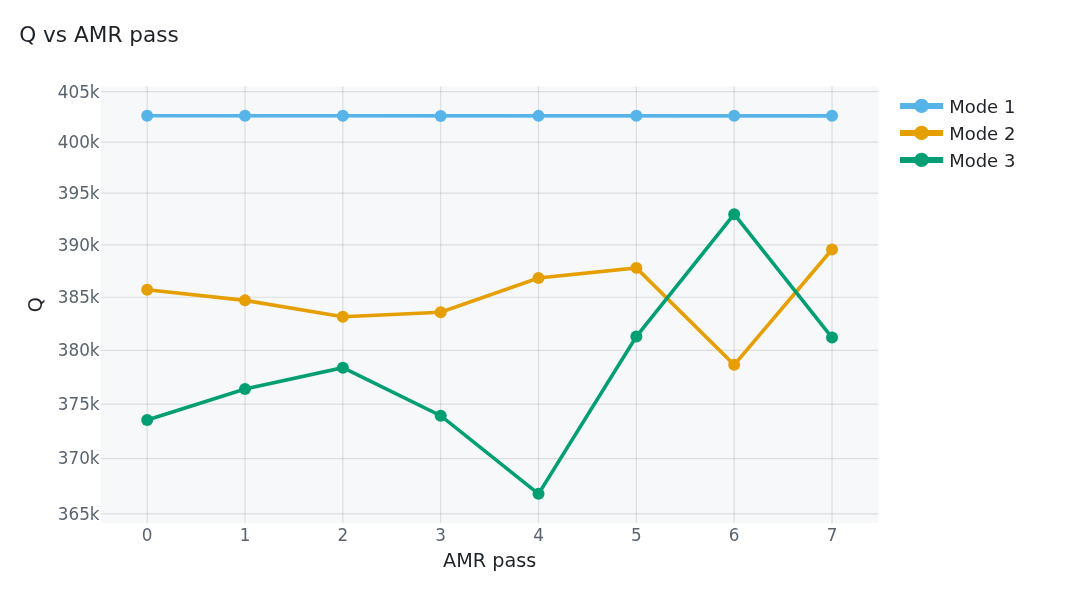

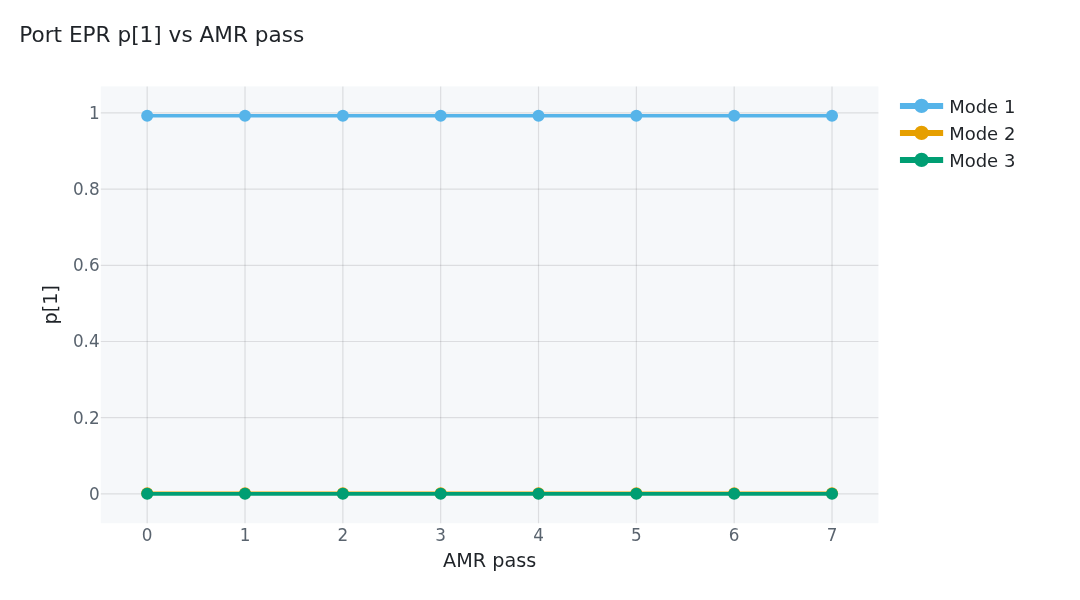

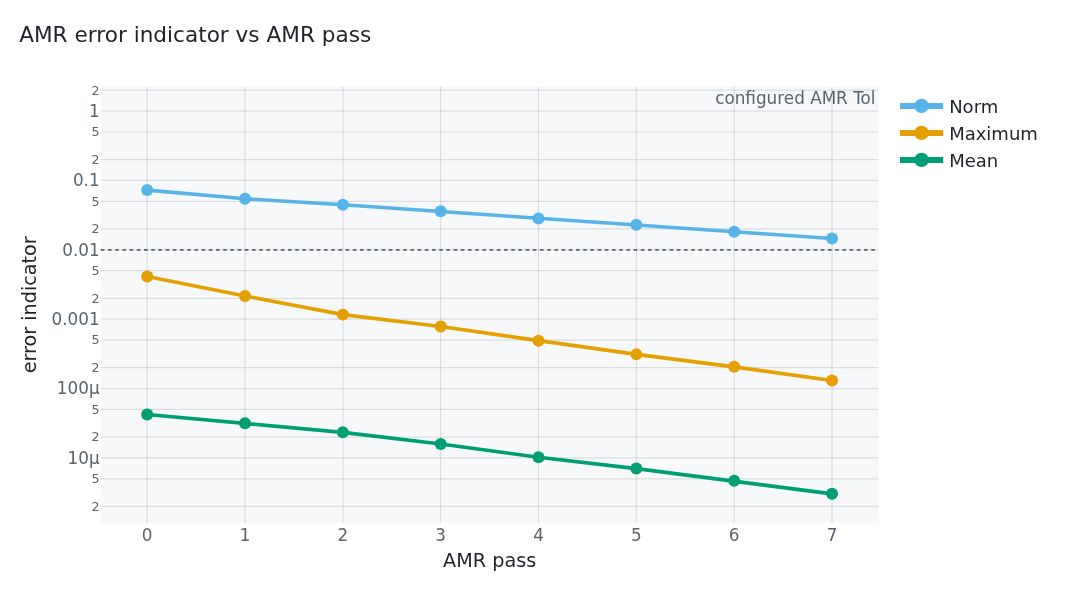

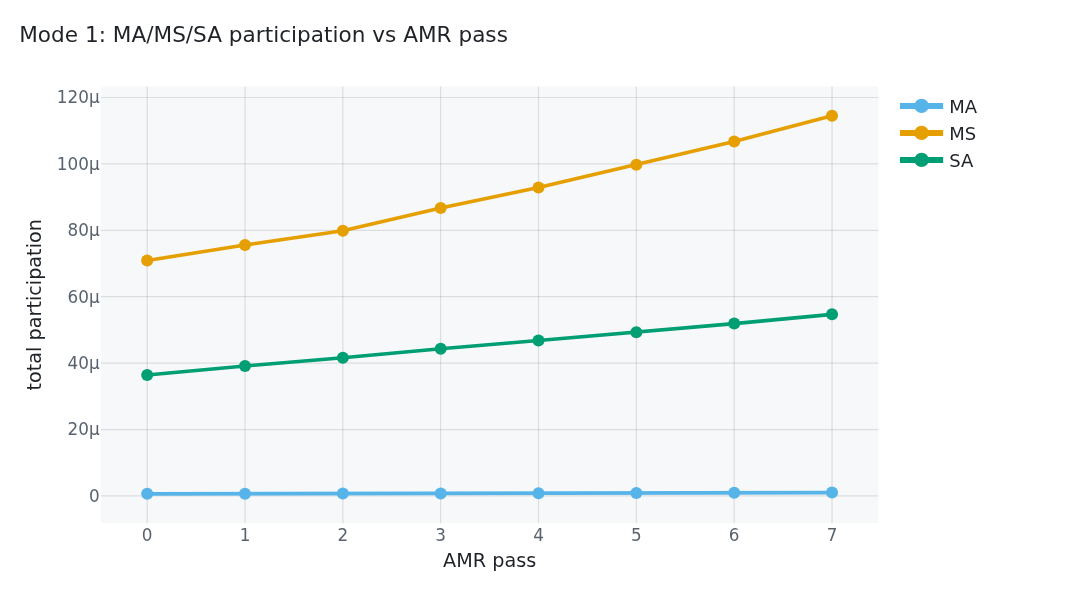

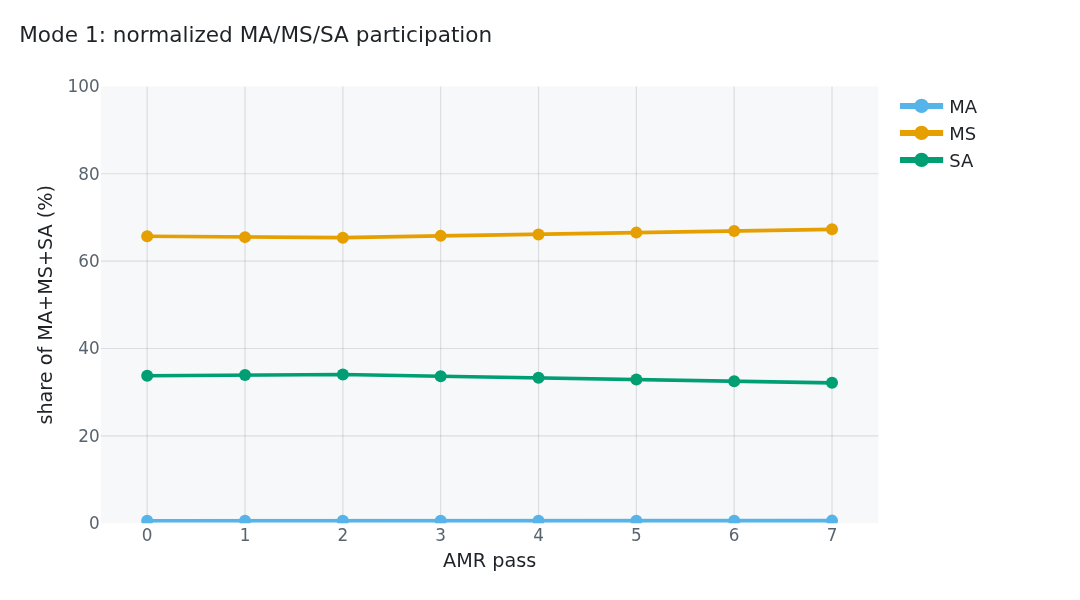

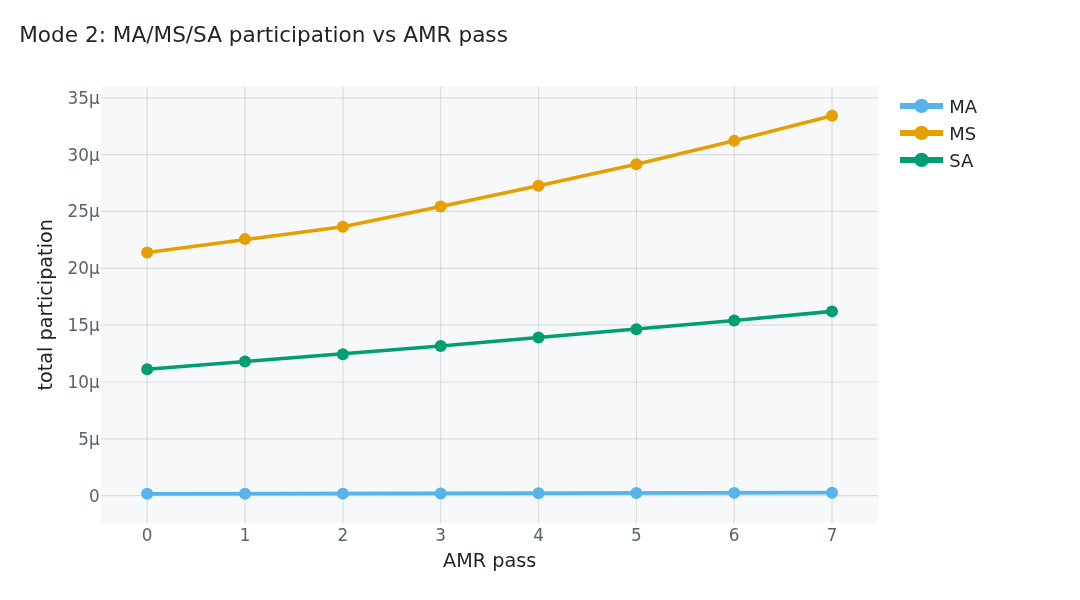

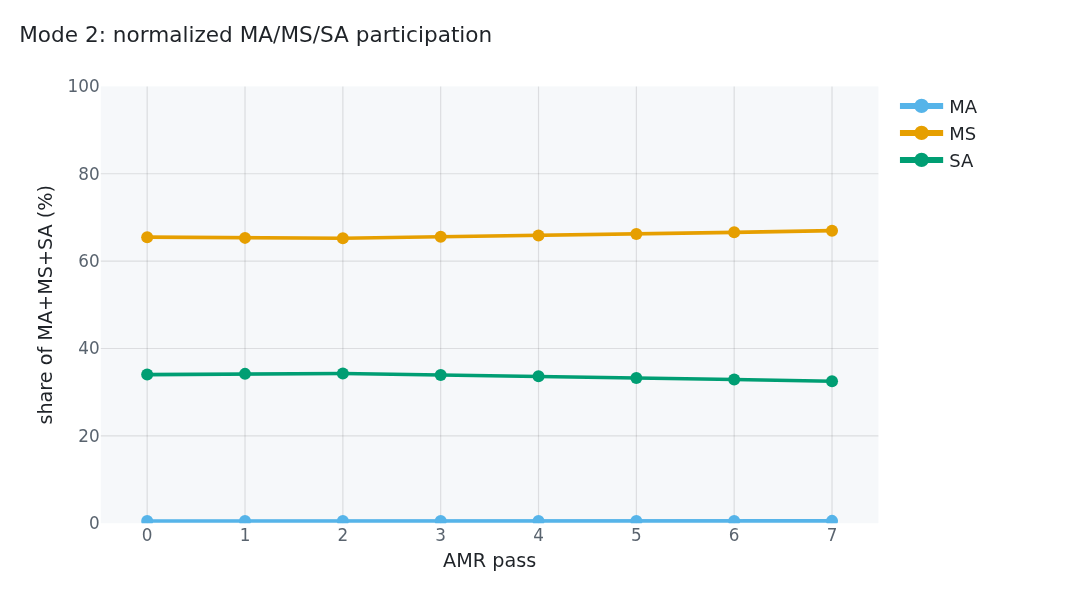

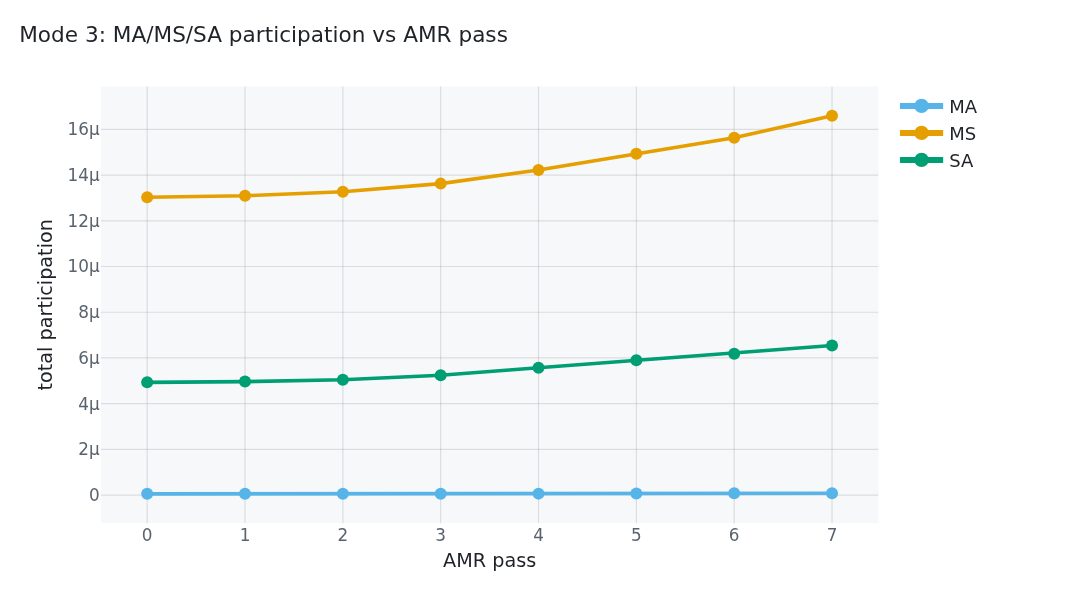

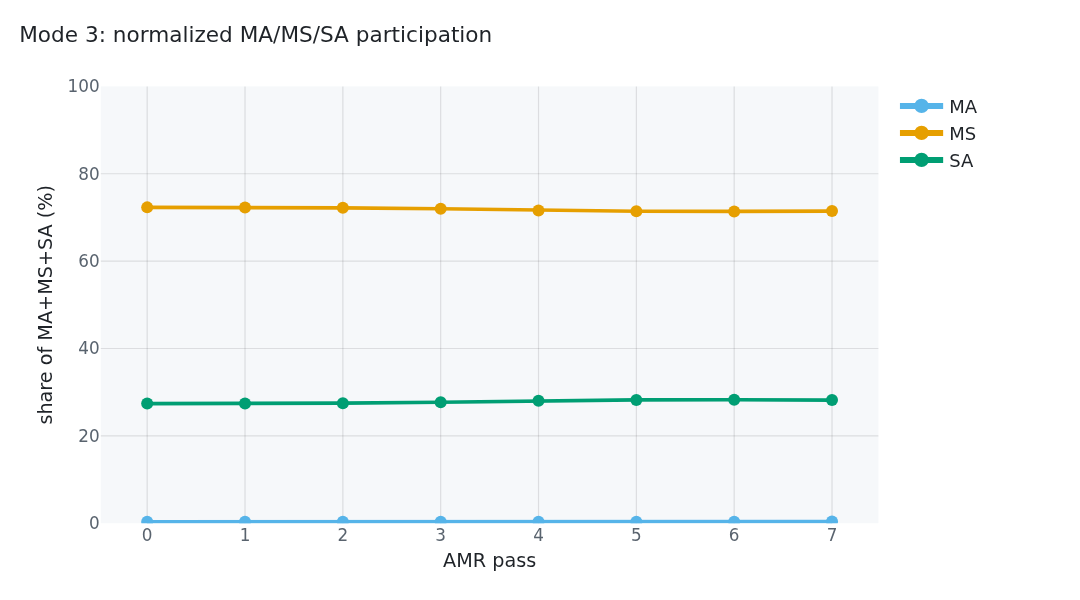

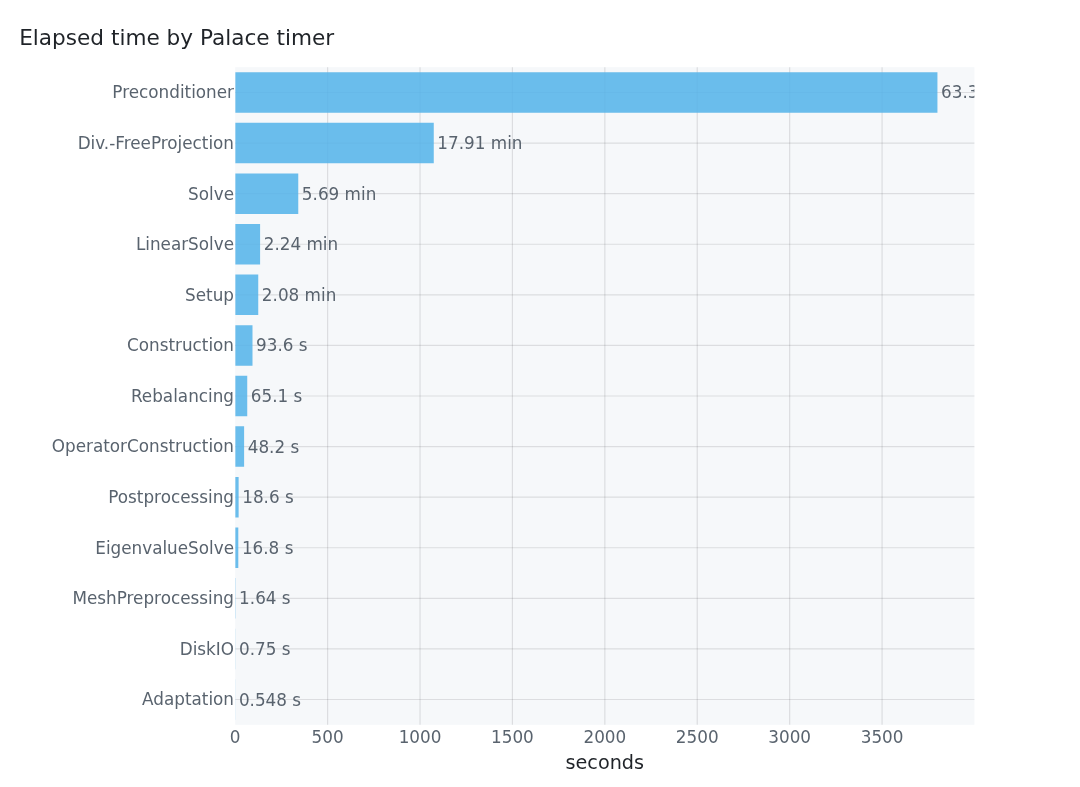

Pass,Snapshot,DOFs,Mesh elems,This pass,Cumulative,s / MDoF,Peak node mem
0,iteration01,3253854,158178,111 s,111 s,34.1596,49.43 GiB
1,iteration02,4330104,215732,2.31 min,4.17 min,32.0585,74.02 GiB
2,iteration03,5950074,302073,3.54 min,7.70 min,35.6714,95.03 GiB
3,iteration04,8842737,456377,5.45 min,13.15 min,36.9665,119.64 GiB
4,iteration05,13918017,726896,9.64 min,22.79 min,41.5516,168.06 GiB
5,iteration06,20568225,1081369,14.58 min,37.37 min,42.5435,237.06 GiB
6,iteration07,31347174,1654853,22.85 min,60.22 min,43.7273,375.42 GiB
7,iteration08,48890130,2589775,39.15 min,99.37 min,48.049,545.55 GiB


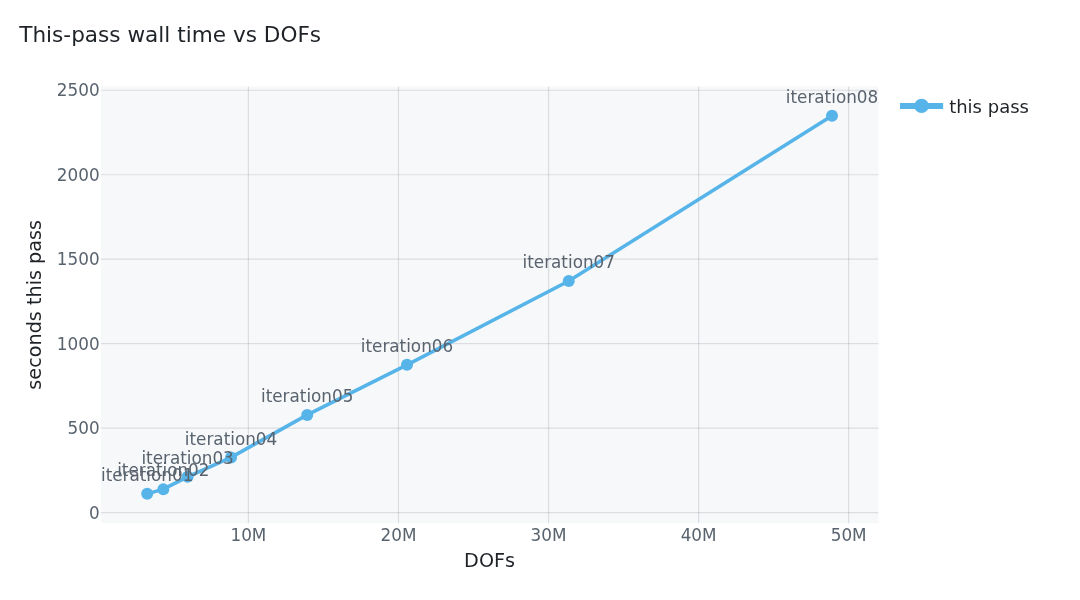

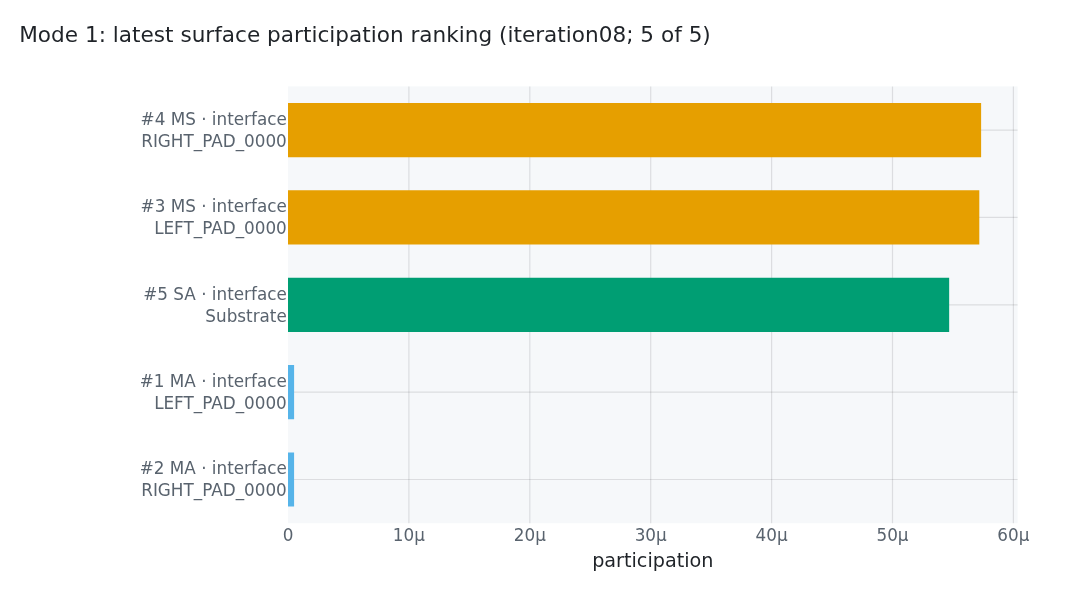

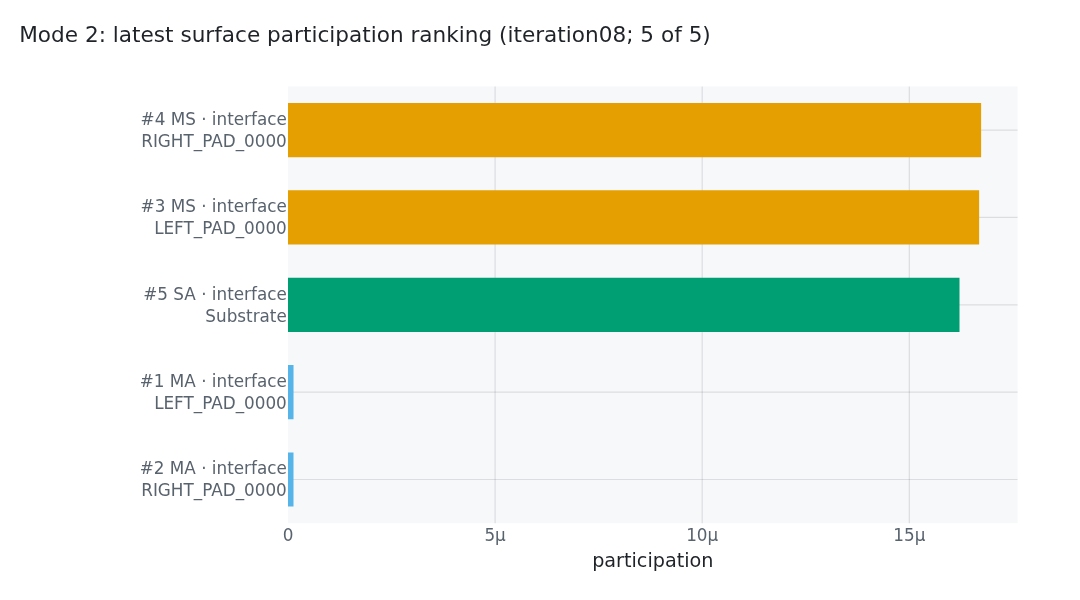

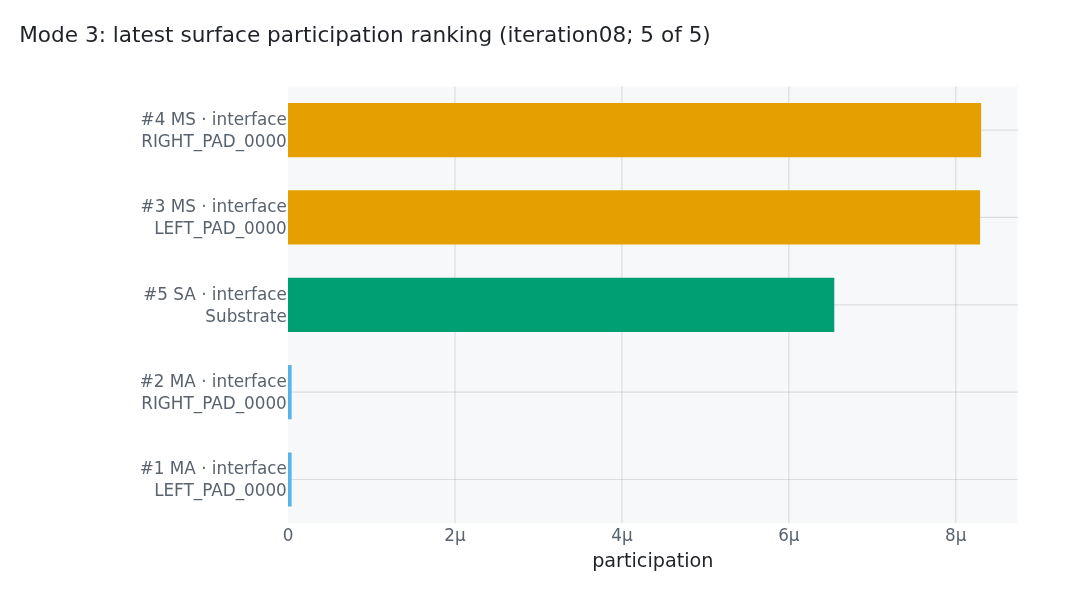

In [7]:
RETURNED_RUN_DIR = RUN_ROOT / "returned" / RUN_ID
EXPECTED_HANDOFF_ID = "c57f6e70ad2436834c20b9b2499a4c997e934b6a7e99cb2ebf0514f28eef499f"
REPORT_THEME = "light"
SURFACE_RANKING_LIMIT = 20

if WORKFLOW_ACTION == "prepare":
    preview = inspect_palace_geometry(RUN_DIR)
    display(preview.show_surface_epr())

if WORKFLOW_ACTION == "analyze-returned":
    if not EXPECTED_HANDOFF_ID:
        raise ValueError(
            "Set EXPECTED_HANDOFF_ID to the exact ID recorded during preparation."
        )
    returned_trust = inspect_run_trustworthiness(RETURNED_RUN_DIR, theme=REPORT_THEME)
    if returned_trust.identity["handoff_id"] != EXPECTED_HANDOFF_ID:
        raise ValueError("Returned run handoff ID does not match EXPECTED_HANDOFF_ID.")
    analysis = (
        resolve_palace_result(
            RETURNED_RUN_DIR,
            expected_handoff_id=EXPECTED_HANDOFF_ID,
        )
        if returned_trust.completeness == "complete"
        else returned_trust
    )
    if not analysis.show_physics_quantities(
        theme=REPORT_THEME,
        ranking_limit=SURFACE_RANKING_LIMIT,
    ).snapshots:
        raise RuntimeError(
            "Returned run has no Surface-EPR snapshots bound to structured semantics."
        )
    analysis.show_all_results(theme=REPORT_THEME, ranking_limit=SURFACE_RANKING_LIMIT)